In [1]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc

!pip install konlpy

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
86 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest version (17.0.17+10-1~24.04).
0 upgraded, 0 newly installed, 0 to remove and 86 not upgraded.


In [2]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")
file_name = os.path.join(data_dir, "synopsis.txt")

with open(file_name, 'r') as file:
    for i in range(20):
        print(file.readline(), end='')

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.
 은수를 잊지 못하는 상우는 미련과 집착의 감정을 이기지 못하고 서울과 강릉을 오간다.
유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 '애국심'이라는 성역에 일침을 가하는 다큐멘터리. 재작년 전국 민족민주 유가족협의회의 장기농성을 다룬 인상적인 다큐멘터리 <민들레>를 만들었던 독립영화집단 '빨간 눈사람'이 우리 사회 구석구석을 발빠르게 돌아다니며 애국심과 민족주의가 강요되는 현장을 발굴하여 카메라에 담았다. 박홍 서강대 명예총장, 이도형 '한국논단' 발행인, 축구해설자 신문선, 홍세화, 박노해 등 사회 각계의 '스타'들이 등장해 저마다의 확고한 신념을 성토한다. 감독 이경순과 최하동하는 이 작품을 위해 3년간 백여 명을 인터뷰했다고 한다. 2001 올해의 독립영화상 수상.
 민족과 국가란 공동체에서 부단히 권력과 부를 얻는 자, 나아가 민족과 국가란 공동체에서 얻은 신분과 부귀를 영원히 그의 자손에게 대물림하려는 자, 그래서 민족과 국가란 공동체를 부단히 유지해야만 하는 자, 따라서

In [3]:
!pip install nltk==3.6.7
!pip install gensim==4.3.2
!pip install scipy==1.12.0 numpy==1.26.2

In [4]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.3.2
1.7.0
0.13.2


In [5]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

In [6]:
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

# 파일 읽기 및 명사 추출하기
def read_token(file_name):
    okt = Okt()
    result = []
    print(f"{file_name} 파일을 읽고있습니다.")

    with open(os.getenv('HOME') + '/work/weat/data/' + file_name, 'r') as fread:
        while True:
            line = fread.readline()
            if not line: break

            # 형태소 분석 (Stemming, Normalization 적용)
            tokenlist = okt.pos(line, stem=True, norm=True)

            # 명사만 골라서 담기
            for word in tokenlist:
                if word[1] in ["Noun"]:
                    result.append(word[0])
        return ' '.join(result)

In [7]:

art = read_token(art_txt)
gen = read_token(gen_txt)
     


synopsis_art.txt 파일을 읽고있습니다.
synopsis_gen.txt 파일을 읽고있습니다.


In [8]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])

print(X.shape)

(2, 41082)


In [9]:
genre_data = []
for file_name in genre_txt:
    genre_data.append(read_token(file_name))

synopsis_SF.txt 파일을 읽고있습니다.
synopsis_family.txt 파일을 읽고있습니다.
synopsis_show.txt 파일을 읽고있습니다.
synopsis_horror.txt 파일을 읽고있습니다.
synopsis_etc.txt 파일을 읽고있습니다.
synopsis_documentary.txt 파일을 읽고있습니다.
synopsis_drama.txt 파일을 읽고있습니다.
synopsis_romance.txt 파일을 읽고있습니다.
synopsis_musical.txt 파일을 읽고있습니다.
synopsis_mystery.txt 파일을 읽고있습니다.
synopsis_crime.txt 파일을 읽고있습니다.
synopsis_historical.txt 파일을 읽고있습니다.
synopsis_western.txt 파일을 읽고있습니다.
synopsis_adult.txt 파일을 읽고있습니다.
synopsis_thriller.txt 파일을 읽고있습니다.
synopsis_animation.txt 파일을 읽고있습니다.
synopsis_action.txt 파일을 읽고있습니다.
synopsis_adventure.txt 파일을 읽고있습니다.
synopsis_war.txt 파일을 읽고있습니다.
synopsis_comedy.txt 파일을 읽고있습니다.
synopsis_fantasy.txt 파일을 읽고있습니다.


In [10]:
from gensim.models import Word2Vec

all_data = [art, gen] + genre_data
tokenized_data = [text.split() for text in all_data]

model = Word2Vec(sentences=tokenized_data, vector_size=100, window=5, min_count=3, sg=0)

In [11]:
print(X.shape)

(2, 41082)


In [12]:
model.wv.most_similar(positive=['영화'])

[('작품', 0.9996086359024048),
 ('디지털', 0.9991433024406433),
 ('한국', 0.9991102814674377),
 ('작', 0.9988401532173157),
 ('홍콩', 0.9986428618431091),
 ('특별', 0.9984428286552429),
 ('소개', 0.998325765132904),
 ('국내', 0.9982485771179199),
 ('환경', 0.9982239007949829),
 ('베를린', 0.9981812238693237)]

In [13]:
model.wv.most_similar(positive=['사랑'])

[('남자', 0.9994407892227173),
 ('서로', 0.9989277720451355),
 ('그녀', 0.9986757040023804),
 ('사람', 0.9982786774635315),
 ('그', 0.9979315996170044),
 ('두', 0.9972279071807861),
 ('둘', 0.9970555901527405),
 ('다른', 0.9967324733734131),
 ('여자', 0.9963946342468262),
 ('것', 0.9961572289466858)]

In [14]:
# TF-IDF
vectorizer = TfidfVectorizer()
X_total = vectorizer.fit_transform(all_data)

# 중복없는 대표 단어 추출
def get_distinct_words(target_idx, vectorizer, X, n=15, exclude_list=[]):
    m = X[target_idx].tocoo()
    w = [[i, j] for i, j in zip(m.col, m.data)]
    w.sort(key=lambda x: x[1], reverse=True) # 내림차순

    final_words = []
    for i in range(len(w)):
        word = vectorizer.get_feature_names_out()[w[i][0]]

        if (word in model.wv) and (word not in exclude_list):
            final_words.append(word)

        if len(final_words) == n: break

    return final_words

# Target 단어 추출 (예술 과 일반)
target_art = get_distinct_words(0, vectorizer, X_total, n=15)
target_gen = get_distinct_words(1, vectorizer, X_total, n=15)

print(f'예술영화 대표 단어: {target_art[:10]}')
print(f'일반영화 대표 단어: {target_gen[:10]}')

예술영화 대표 단어: ['그녀', '자신', '시작', '위해', '사랑', '사람', '영화', '친구', '남자', '가족']
일반영화 대표 단어: ['자신', '그녀', '영화제', '위해', '사람', '시작', '국제', '영화', '친구', '사랑']


In [15]:
print(vectorizer.vocabulary_['영화'])
print(vectorizer.get_feature_names_out()[23976])

24952
엉터리


In [16]:
# Attribute 단어 추출
stop_words = target_art + target_gen
attributes = []

for i in range(len(genre_data)):
    attr = get_distinct_words(i+2, vectorizer, X_total, n=15, exclude_list=stop_words)
    attributes.append(attr)

In [17]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

# WEAT 계산 함수 정의
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A, mean_B

def weat_score(X, Y, A, B):
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)
    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)
    std_dev = np.std(np.concatenate([s_X, s_Y]))
    return (mean_X - mean_Y) / std_dev

In [20]:
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]



In [21]:
X_vec = np.array([model.wv[word] for word in target_art])
Y_vec = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)):
    for j in range(len(genre_name)):
        if i == j: continue # 같은 장르끼리는 0

        A_vec = np.array([model.wv[word] for word in attributes[i]])
        B_vec = np.array([model.wv[word] for word in attributes[j]])

        matrix[i][j] = weat_score(X_vec, Y_vec, A_vec, B_vec)

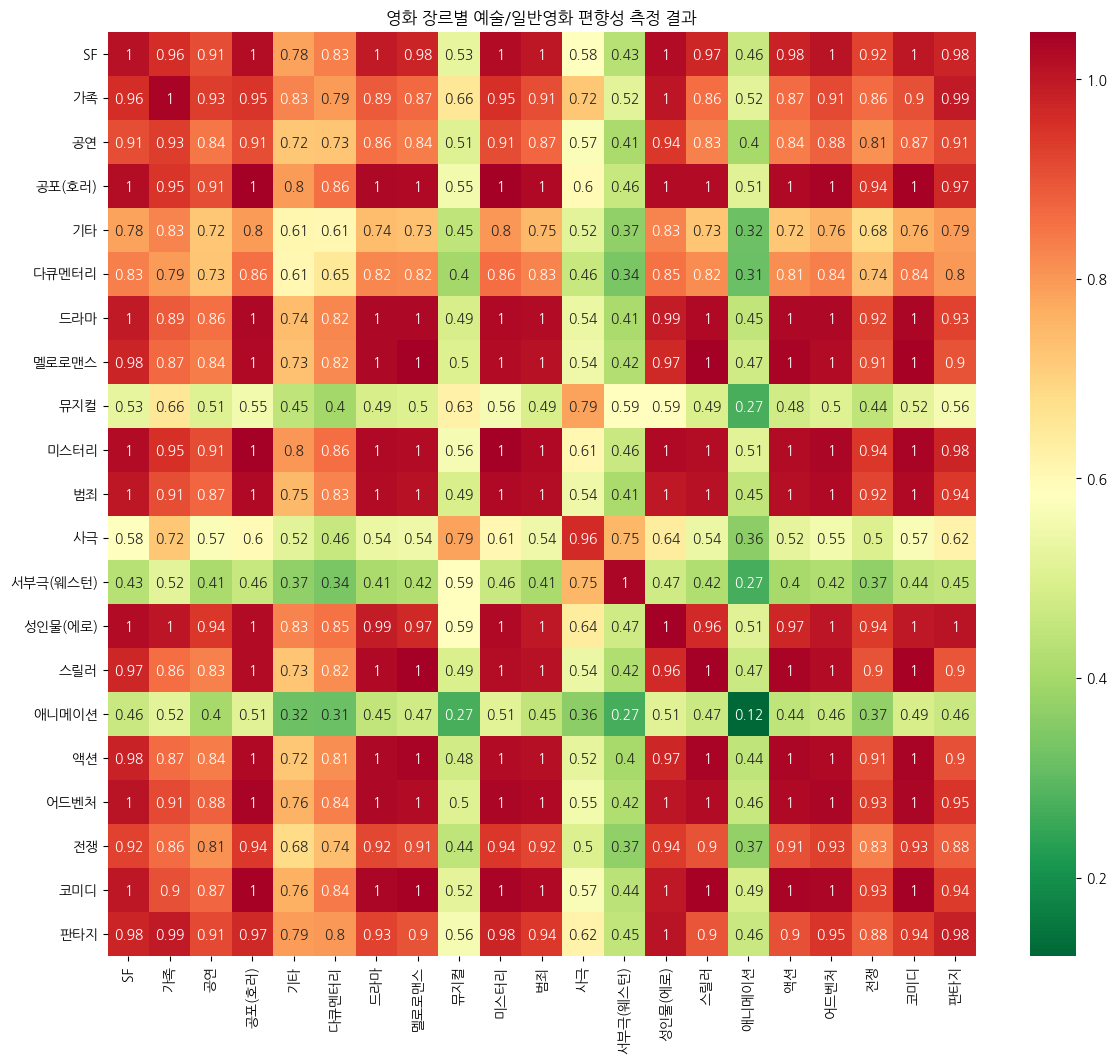

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_attributes = len(attributes)
matrix = np.zeros((num_attributes, num_attributes))

# 2. Target 데이터 설정
X_vec = np.array([model.wv[word] for word in target_art])
Y_vec = np.array([model.wv[word] for word in target_gen])


for i in range(num_attributes):
    for j in range(num_attributes):
        
        if len(attributes[i]) == 0 or len(attributes[j]) == 0:
            matrix[i][j] = 0
            continue

        A_vec = np.array([model.wv[word] for word in attributes[i]])
        B_vec = np.array([model.wv[word] for word in attributes[j]])

        # weat_score 계산
        score = weat_score(X_vec, Y_vec, A_vec, B_vec)

        # NaN(계산불가) 값이 나오면 0으로 처리
        matrix[i][j] = score if not np.isnan(score) else 0


plt.figure(figsize=(14, 12))
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


display_names = genre_name[:num_attributes]

sns.heatmap(matrix, xticklabels=display_names, yticklabels=display_names, annot=True, cmap='RdYlGn_r')
plt.title("영화 장르별 예술/일반영화 편향성 측정 결과")
plt.show()